# Proyek Machine Learning Pemula: Beverage Sales Dataset 
- **Nama:** Audy Nadira Ramadanti
- **Email:** audynadiraramdanti@gmail.com
- **ID Dicoding:** audy_nadira_ramadanti_zWZ9

# **1. Import Library**

In [1]:
#Type your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


Sebelum memulai pemrosesan data, saya memerlukan beberapa library yang membantu dalam pengolahan, analisis, dan visualisasi data, serta penerapan algoritma clustering. Berikut adalah penjelasan singkat mengenai masing-masing library dan fungsi yang diimpor:

**1. `pandas` (`import pandas as pd`)**  
   - Digunakan untuk **manipulasi dan analisis data**.  
   - Memiliki struktur data **DataFrame** dan **Series** yang memudahkan operasi seperti membaca, menulis, menggabungkan, dan memfilter data.

**2. `NumPy` (`import numpy as np`)**  
   - Menyediakan **array multidimensi** yang efisien dan berbagai fungsi matematika untuk perhitungan numerik.  
   - Sering digunakan bersama Pandas untuk melakukan operasi numerik yang lebih kompleks.

**3. `matplotlib.pyplot` (`import matplotlib.pyplot as plt`)**  
   - Memungkinkan pembuatan **grafik dan visualisasi data** dasar, seperti plot garis, histogram, dan scatter plot.  
   - Sangat fleksibel dan dapat dikustomisasi untuk berbagai jenis visualisasi.

**4. `seaborn` (`import seaborn as sns`)**  
   - Memperluas Matplotlib dengan **tampilan visualisasi statistik** yang lebih menarik dan mudah dipahami.  
   - Memiliki fungsi bawaan untuk membuat plot seperti heatmap, boxplot, dan pairplot secara lebih sederhana.

**5. `OneHotEncoder` (`from sklearn.preprocessing import OneHotEncoder`)**  
   - Digunakan untuk **mengubah (encode) fitur kategorikal** menjadi variabel dummy (kolom biner).  
   - Sangat berguna ketika fitur kategorikal tidak bersifat ordinal dan memiliki beberapa kategori unik.

**6. `LabelEncoder` (`from sklearn.preprocessing import LabelEncoder`)**  
   - Mengubah nilai kategori menjadi **label numerik** (misalnya 0, 1, 2, dst.).  
   - Cocok untuk kasus di mana kolom kategorikal bisa diwakili oleh integer label tanpa perlu menambah banyak kolom baru.

**7. `MinMaxScaler` (`from sklearn.preprocessing import MinMaxScaler`)**  
   - Digunakan untuk **menormalisasi** atau **menskalakan** data numerik ke dalam rentang tertentu, biasanya [0, 1].  
   - Membantu algoritma *machine learning* yang sensitif terhadap skala data agar kinerjanya lebih optimal.

**8. `train_test_split` (`from sklearn.model_selection import train_test_split`)**  
   - Memudahkan **pembagian dataset** menjadi **data latih** dan **data uji** secara acak.  
   - Membantu dalam memvalidasi model dengan mengecek performa pada data yang belum pernah dilihat sebelumnya.

**9. `classification_report` (`from sklearn.metrics import classification_report`)**  
   - Memberikan **ringkasan metrik evaluasi** untuk tugas klasifikasi, seperti **precision**, **recall**, dan **f1-score**.  
   - Memudahkan kita untuk melihat performa model di setiap kelas secara rinci.

**10. `accuracy_score` (`from sklearn.metrics import accuracy_score`)**  
   - Menghitung **akurasi** model klasifikasi, yaitu persentase prediksi benar dari keseluruhan data uji.  
   - Salah satu metrik umum untuk menilai performa model klasifikasi.

**11. `LogisticRegression` (`from sklearn.linear_model import LogisticRegression`)**  
   - Model klasifikasi yang menggunakan **regresi logistik** untuk memprediksi kelas (0/1).  
   - Sering digunakan sebagai baseline karena sederhana namun cukup efektif.

**12. `RandomForestClassifier` (`from sklearn.ensemble import RandomForestClassifier`)**  
   - Model **ensemble** berbasis banyak *decision tree* yang dikombinasikan secara acak (random) untuk meningkatkan akurasi dan mengurangi *overfitting*.

**13. `xgboost` (`import xgboost as xgb`)**  
   - Model **gradient boosting** yang efisien dan seringkali memberikan performa tinggi dalam berbagai kompetisi data.  
   - Mampu menangani data dengan jumlah fitur besar dan mendukung *regularization* yang baik.

**14. `GridSearchCV` (`from sklearn.model_selection import GridSearchCV`)**  
   - Melakukan **pencarian sistematis** atas kombinasi parameter yang ditentukan untuk menemukan **hyperparameter** optimal.  
   - Menggunakan teknik **cross-validation** dalam proses pencariannya.

**15. `RandomizedSearchCV` (`from sklearn.model_selection import RandomizedSearchCV`)**  
   - Alternatif yang lebih **efisien** daripada GridSearchCV dengan melakukan **pencarian acak** pada ruang parameter.  
   - Cocok untuk ruang parameter yang besar atau waktu komputasi yang terbatas.

**16. `learning_curve` (`from sklearn.model_selection import learning_curve`)**  
   - Digunakan untuk **membuat kurva pembelajaran** yang menunjukkan bagaimana kinerja model berubah dengan bertambahnya data latih.  
   - Membantu mendeteksi apakah model mengalami *overfitting* atau *underfitting*.

**17. `cross_val_score` (`from sklearn.model_selection import cross_val_score`)**  
   - Memungkinkan kita melakukan **evaluasi model** dengan *k-fold cross-validation* secara mudah.  
   - Menghasilkan skor performa di setiap fold, sehingga kita bisa melihat **variabilitas** dan **rata-rata** performa model.

**18. `MLPClassifier` (`from sklearn.neural_network import MLPClassifier`)**  
   - Model **Neural Network** (Multi-Layer Perceptron) dari scikit-learn.  
   - Mampu mempelajari hubungan non-linear dalam data melalui beberapa lapisan tersembunyi.

# **2. Memuat Dataset dari Hasil Clustering**

In [2]:
#Type your code here

data = pd.read_csv("data/Data_Clustering.csv")

Karena sebelumnya kita sudah mendapatkan **label** dari pemodelan klasterisasi dan telah menyimpannya dalam file **CSV** (`Data_Clustering.csv`), selanjutnya saya akan **menggunakannya untuk proses klasifikasi**. Hal ini saya lakukan dengan **menjadikan kolom hasil klasterisasi sebagai target (label)** dalam pendekatan **supervised learning**. Dengan demikian, kita dapat membangun model klasifikasi (misalnya Decision Tree, Random Forest, atau Logistic Regression) yang mampu memprediksi **segmen pelanggan** (label klaster) untuk data baru berdasarkan fitur-fitur yang tersedia.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       10000 non-null  object 
 1   Order_ID          10000 non-null  object 
 2   Unit_Price        10000 non-null  float64
 3   Total_Price       10000 non-null  float64
 4   Quantity          10000 non-null  float64
 5   Discount          10000 non-null  float64
 6   Region            10000 non-null  object 
 7   Cluster           10000 non-null  int64  
 8   Customer_Type     10000 non-null  object 
 9   Customer_Segment  10000 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


Sebelum mulai memproses data, langkah pertama yang saya lakukan adalah **memeriksa struktur dataset** dengan menggunakan `data.info()`. Dari hasil tersebut, dapat dilihat:

- **Jumlah baris**: 10.000  
- **Jumlah kolom**: 10  
- **Tipe data**:  
  - 5 kolom bertipe *object* (`Customer_ID`, `Order_ID`, `Region`, `Customer_Type`, `Customer_Segment`)  
  - 4 kolom bertipe *float64* (`Unit_Price`, `Total_Price`, `Quantity`, `Discount`)  
  - 1 kolom bertipe *int64* (`Cluster`)  
- **Tidak ada missing values** (semua kolom memiliki 10.000 non-null entries).  
- **Penggunaan memori**: sekitar 781.4 KB.

Dengan mengetahui struktur data seperti ini, kita bisa merencanakan **langkah preprocessing** selanjutnya, misalnya:
- Mengecek apakah kolom bertipe *object* perlu diubah ke tipe kategori atau tipe numerik tertentu.  
- Melakukan *feature engineering* jika diperlukan (contoh: menghitung metrik baru dari `Unit_Price` dan `Quantity`, atau menganalisis segmen pelanggan berdasarkan `Customer_Type`).  
- Menentukan metode yang tepat untuk menangani data jika ada anomali (misalnya nilai ekstrem pada `Discount` atau `Total_Price`).  

Langkah awal ini penting agar kita memahami karakteristik dasar dataset sebelum melakukan analisis lebih lanjut.

# **3. Pre-Processing Data**

In [4]:
#Type your code here

data = data.drop(columns=["Customer_ID", "Order_ID"])

Karena menurut saya kolom **`Customer_ID`** dan **`Order_ID`** tidak memberikan informasi yang relevan untuk keperluan pemodelan klasifikasi (umumnya hanya bersifat *identifier* yang unik untuk setiap entitas), saya memutuskan untuk menghapusnya. Proses penghapusan ini dilakukan dengan:

```python
data = data.drop(columns=["Customer_ID", "Order_ID"])
```

Tujuannya adalah untuk menyederhanakan dataset sehingga hanya kolom yang berpotensi memberikan *insight* prediktif yang tersisa. Langkah ini juga membantu **mencegah kebocoran data** (data leakage) serta mengurangi kebisingan (*noise*) yang dapat mempengaruhi kinerja model.

In [5]:
le = LabelEncoder()
data['Region'] = le.fit_transform(data['Region'])

Selanjutnya, saya melakukan **encoding** pada data bersifat kategorikal, khususnya pada fitur **`Region`**. Karena fitur ini memiliki nilai unik yang sangat banyak, saya menggunakan **`LabelEncoder`** agar setiap kategori dapat diubah menjadi representasi numerik. Dengan demikian, model *machine learning* yang umumnya hanya menerima input numerik akan lebih mudah mengolah variabel **`Region`** tanpa kehilangan informasi kategorikalnya.

In [6]:
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' untuk menghindari multikolinearitas
encoded_region = encoder.fit_transform(data[['Customer_Type']])

region_df = pd.DataFrame(encoded_region, columns=encoder.get_feature_names_out(['Customer_Type']))

data = data.drop(columns=['Customer_Type']).reset_index(drop=True)
data = pd.concat([data, region_df], axis=1)

Selanjutnya, saya menerapkan **One Hot Encoding** pada fitur **`Customer_Type`**. Meskipun fitur ini hanya memiliki 2 kategori unik, proses ini tetap diperlukan agar setiap kategori dapat diwakili oleh nilai biner (0 atau 1) yang mudah dipahami oleh model. Selain itu, saya menggunakan parameter **`drop='first'`** untuk menghindari masalah *multicollinearity* atau *dummy variable trap*, di mana salah satu kolom akan menjadi *baseline* dan tidak perlu ditampilkan secara eksplisit. 

Dengan demikian, setelah proses ini, dataset akan memiliki kolom baru yang mewakili kategori **`Customer_Type`** secara numerik, sementara kolom aslinya sudah dihapus agar tidak menimbulkan redundansi.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unit_Price         10000 non-null  float64
 1   Total_Price        10000 non-null  float64
 2   Quantity           10000 non-null  float64
 3   Discount           10000 non-null  float64
 4   Region             10000 non-null  int32  
 5   Cluster            10000 non-null  int64  
 6   Customer_Segment   10000 non-null  object 
 7   Customer_Type_B2C  10000 non-null  float64
dtypes: float64(5), int32(1), int64(1), object(1)
memory usage: 586.1+ KB


Setelah proses *encoding*, saya kembali memeriksa struktur data menggunakan `data.info()`. Hasilnya menunjukkan bahwa:

- Kolom **`Region`** kini sudah bertipe numerik (`int32`) berkat proses *label encoding*.  
- Kolom **`Customer_Type_B2C`** juga telah ditambahkan sebagai kolom baru dengan tipe *float64*, menandakan bahwa *one-hot encoding* berhasil dilakukan.  
- Kolom **`Customer_Segment`** masih bertipe *object*, sehingga jika dibutuhkan, kita bisa melakukan proses encoding lebih lanjut di kolom tersebut.

Dengan demikian, data yang bersifat kategorikal telah berubah menjadi numerik sesuai yang diharapkan, dan kita siap melanjutkan proses *preprocessing* atau analisis/pemodelan selanjutnya.

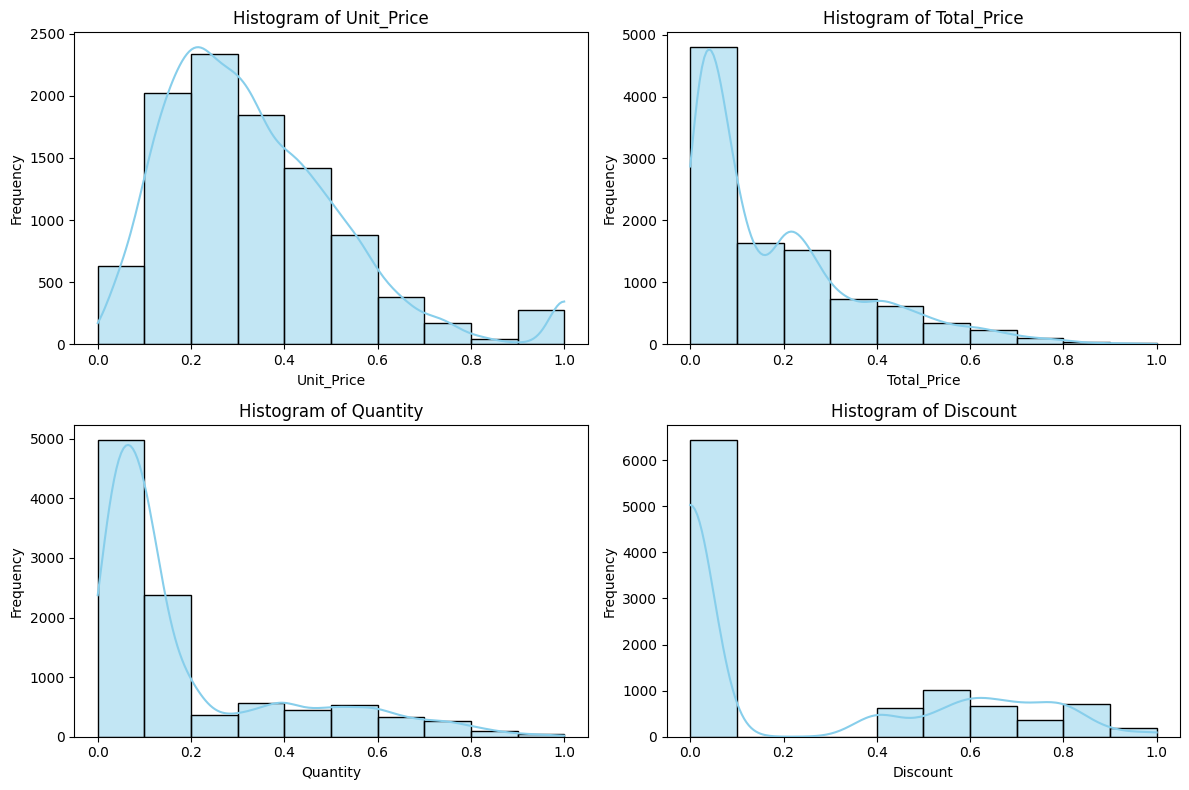

In [8]:
scaler = MinMaxScaler()
columns_to_normalize = ['Unit_Price', 'Total_Price', 'Quantity', 'Discount']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# Plot histogram
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_normalize, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=10, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Terakhir, sebelum memasuki tahap pemodelan, saya melakukan **normalisasi data** menggunakan **`MinMaxScaler`** pada kolom-kolom numerik, yaitu **`Unit_Price`, `Total_Price`, `Quantity`, dan `Discount`**. Tujuan normalisasi ini adalah untuk **menskalakan** setiap fitur numerik ke rentang [0, 1], sehingga:

1. **Rentang nilai** menjadi seragam dan tidak ada fitur yang memiliki skala jauh lebih besar dibandingkan fitur lainnya.  
2. **Algoritma pemodelan**—terutama yang sensitif terhadap skala data (misalnya *k-Nearest Neighbors* atau *Neural Networks*)—dapat bekerja lebih optimal.  

Setelah normalisasi, saya juga **memvisualisasikan histogram** untuk memeriksa distribusi data hasil normalisasi. Dengan demikian, kita bisa memastikan bahwa proses normalisasi berjalan sesuai harapan dan siap melanjutkan ke tahap pemodelan.

# **4. Data Splitting**

In [9]:
#Type your code here

X = data.drop(columns=["Customer_Segment"])  # Fitur
y = data["Customer_Segment"]  # Target
y_encoded = le.fit_transform(y)

Sebelum memasuki tahap pemodelan, saya memisahkan dataset menjadi **fitur (X)** dan **target (y)**. Di sini, **`Customer_Segment`** menjadi target yang akan diprediksi, sedangkan **X** berisi semua kolom lainnya. Karena **`Customer_Segment`** masih bersifat kategorikal, saya menerapkan **`LabelEncoder`** untuk mengubah nilai kategorikal menjadi nilai numerik dan menyimpannya dalam **`y_encoded`**. Langkah ini diperlukan agar model *machine learning* dapat memproses target dengan format numerik.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded , random_state=42, test_size=0.3, shuffle=True) 

Saya membagi data menjadi **data latih (X_train, y_train)** dan **data uji (X_test, y_test)** dengan proporsi 70% data latih dan 30% data uji (ditentukan oleh `test_size=0.3`). Saya juga menggunakan parameter `shuffle=True` untuk mengacak urutan data sebelum pembagian, serta `random_state=42` agar proses pembagian ini **reproducible**—sehingga jika kode dijalankan kembali, hasil pembagian akan sama.  

# **5. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [ ]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


# 2. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# 3. Multi Layer Perceptron
mlp_model = MLPClassifier(random_state=42, max_iter=1000)  
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)


Masuk ke dalam tahap pemodelan klasifikasi disini saya menggunakan **tiga algoritma klasifikasi** untuk memprediksi **Customer_Segment**:

1. **Logistic Regression**  
   - Menggunakan **regresi logistik** dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Setelah proses pelatihan dengan data latih (`X_train`, `y_train`), saya menghasilkan prediksi (`y_pred_lr`) pada data uji (`X_test`).

2. **Random Forest Classifier**  
   - Model **ensemble** yang terdiri dari banyak *decision tree* dengan `n_estimators=100` dan `random_state=42`.  
   - Dilatih pada data latih, kemudian digunakan untuk memprediksi data uji (`y_pred_rf`).

3. **Multi Layer Perceptron (MLP)**  
   - **Neural Network** sederhana dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Dilatih dengan data latih, dan prediksi dihasilkan untuk data uji (`y_pred_mlp`).

Dengan menggunakan ketiga model ini, saya dapat membandingkan kinerja dan memilih model yang paling baik dalam memprediksi **Customer_Segment**.

## **b. Evaluasi Model Klasifikasi**

In [ ]:
#Type your code here

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")

print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")

print("MLP Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Logistic Regression
Accuracy: 0.8273333333333334
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1511
           1       0.79      0.89      0.84      1489

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



Random Forest Classifier
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1511
           1       1.00      1.00      1.00      1489

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



MLP Classifier (Tanpa Tuning)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1511
           1       1.00      1.00      1.00      1489

    accuracy                           1.00   

Hasil dari ketiga model tersebut menunjukkan:

1. **Logistic Regression**  
   - Mencapai akurasi sekitar **82.73%**, dengan **precision**, **recall**, dan **f1-score** yang cukup seimbang.  
   - Ini menandakan performa yang cukup baik, namun masih ada ruang untuk perbaikan.

2. **Random Forest Classifier**  
   - Mencapai akurasi **100%**, dengan nilai precision, recall, dan f1-score sempurna di data uji.  
   - Hasil ini tergolong **sangat tinggi** dan tidak biasa terjadi pada kasus nyata. Bisa disebabkan oleh:  
     - Dataset yang relatif mudah diprediksi,  
     - Ukuran data yang mungkin kurang besar, atau  
     - Adanya *data leakage* (meski belum tentu, tetapi patut diwaspadai).

3. **MLP Classifier**  
   - Sama seperti Random Forest, MLP juga memperoleh **akurasi 100%** di data uji.  
   - Kondisi ini mengindikasikan bahwa model dapat mengenali pola data secara sempurna, sehingga kita perlu melakukan **pengecekan lebih lanjut** untuk memastikan apakah hal ini benar-benar mencerminkan performa model yang baik atau ada faktor lain (misalnya jumlah data terbatas atau karakteristik dataset yang sangat mudah diprediksi).

Secara keseluruhan, **Logistic Regression** memberikan hasil yang realistis namun lebih rendah, sedangkan **Random Forest** dan **MLP** menunjukkan hasil sempurna yang perlu diinvestigasi lebih lanjut guna memastikan tidak terjadi overfitting atau ketidakseimbangan data yang terlalu mudah.

## **c. Tuning Model Klasifikasi (Optional)**

In [ ]:
#Type your code here

# 1. Logistic Regression dengan GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # untuk l1 gunakan solver liblinear
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)


# 2. Random Forest Classifier dengan RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rand_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                             param_distributions=param_dist_rf,
                             n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rand_rf.fit(X_train, y_train)



from sklearn.model_selection import GridSearchCV

# Contoh parameter grid
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (50, 50), (100,)],   # Contoh variasi layer
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive']
}

mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=1000),
    param_grid_mlp,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)

mlp_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (50, 50), (100,)],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['adam', 'sgd']},
             scoring='accuracy')

Selanjutnya, saya kembali menerapkan **tiga algoritma** tersebut (**Logistic Regression**, **Random Forest**, dan **MLP**) namun dengan **strategi hyperparameter tuning**. Tujuannya adalah untuk mencari kombinasi parameter yang **optimal**, sehingga kinerja model dapat meningkat. Berikut pendekatan yang dilakukan:

1. **Logistic Regression (GridSearchCV)**  
   - Saya menggunakan **GridSearchCV** dengan beberapa variasi parameter seperti `C`, `penalty`, dan `solver`.  
   - **GridSearchCV** akan mencoba semua kombinasi parameter dalam `param_grid_lr` menggunakan *k-fold cross-validation*, lalu memilih kombinasi dengan **akurasi** terbaik.

2. **Random Forest Classifier (RandomizedSearchCV)**  
   - Untuk **Random Forest**, saya memanfaatkan **RandomizedSearchCV**, di mana parameter seperti `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, dan `bootstrap` di-*sampling* secara acak dari daftar yang ditentukan.  
   - **RandomizedSearchCV** lebih efisien daripada GridSearchCV ketika ruang parameter cukup besar, karena tidak mencoba semua kombinasi melainkan **hanya sejumlah iterasi** (ditentukan oleh `n_iter`).

3. **MLPClassifier (GridSearchCV)**  
   - Untuk **MLP**, saya kembali menggunakan **GridSearchCV** dengan variasi parameter `hidden_layer_sizes`, `activation`, `solver`, dan `learning_rate`.  
   - Prosesnya serupa dengan Logistic Regression, yaitu memeriksa semua kombinasi parameter lalu memilih yang terbaik berdasarkan **akurasi**.

Dengan cara ini, setiap model berpeluang menunjukkan performa maksimal setelah melalui pencarian parameter terbaik, dibandingkan dengan penggunaan parameter default.

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

In [14]:
#Type your code here

print("Best parameters for Logistic Regression:", grid_lr.best_params_)
y_pred_lr = grid_lr.predict(X_test)
print("Logistic Regression Accuracy After Tuning:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")



print("Best parameters for Random Forest:", rand_rf.best_params_)
y_pred_rf = rand_rf.predict(X_test)
print("Random Forest Accuracy After Tuning:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")


print("Best parameters for MLP:", mlp_grid.best_params_)
y_pred_mlp_tuned = mlp_grid.predict(X_test)
print("MLP Accuracy After Tuning:", accuracy_score(y_test, y_pred_mlp_tuned))
print(classification_report(y_test, y_pred_mlp_tuned))


Best parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Logistic Regression Accuracy After Tuning: 0.851
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1511
           1       0.83      0.88      0.85      1489

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



Best parameters for Random Forest: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'bootstrap': False}
Random Forest Accuracy After Tuning: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1511
           1       1.00      1.00      1.00      1489

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



Best parameters for

Berdasarkan hasil tuning di atas, dapat kita lihat bahwa:

1. **Logistic Regression**  
   - Setelah proses tuning dengan kombinasi parameter terbaik (`C=0.01`, `penalty='l2'`, `solver='liblinear'`), akurasi meningkat dari sekitar **82.73%** menjadi **85.1%**.  
   - Terjadi perbaikan pada metrik **precision**, **recall**, dan **f1-score**, khususnya untuk kedua kelas.

2. **Random Forest**  
   - Meskipun sudah dilakukan tuning dengan parameter terbaik (`n_estimators=50`, `min_samples_split=5`, `min_samples_leaf=2`, `max_depth=20`, `bootstrap=False`), model ini masih menunjukkan **akurasi 100%**.  
   - Hasil sempurna ini patut diinvestigasi lebih lanjut karena jarang terjadi di kasus nyata, misalnya apakah dataset memang sangat mudah diprediksi atau ada faktor lain.

3. **MLPClassifier**  
   - Setelah tuning dengan parameter terbaik (`activation='relu'`, `hidden_layer_sizes'=(50,)`, `learning_rate='constant'`, `solver='adam'`), akurasi juga tetap **100%**.  
   - Seperti pada Random Forest, hasil yang sempurna ini memerlukan pengecekan lebih lanjut untuk memastikan tidak terjadi overfitting atau karakteristik data yang terlalu sederhana.

Secara keseluruhan, **Logistic Regression** mengalami peningkatan kinerja setelah tuning, sementara **Random Forest** dan **MLP** masih memberikan hasil sempurna di data uji. Meskipun tampak sangat baik, akurasi 100% perlu diverifikasi agar dapat dipastikan model tersebut benar-benar dapat *generalize* di luar data latih.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

## 1. Apakah Hasil Setelah Tuning Lebih Baik

Berdasarkan data evaluasi yang diperlihatkan saya menyimpukan seperti dibawh ini:

- **Logistic Regression:**  
  - **Sebelum tuning:** Akurasi sebesar 82.73% dengan nilai precision, recall, dan f1-score yang menunjukkan performa yang cukup baik, namun masih ada ruang untuk peningkatan.  
  - **Setelah tuning:** Akurasi meningkat menjadi 85.1% dan terdapat perbaikan pada nilai precision, recall, serta f1-score untuk kedua kelas.  
  - **Kesimpulan:** Tuning memberikan dampak positif terhadap model Logistic Regression dengan meningkatkan kinerja klasifikasi secara keseluruhan.

- **Random Forest dan XGBoost:**  
  - **Sebelum tuning:** Kedua model telah mencapai performa sempurna dengan akurasi 100% dan nilai metrik evaluasi lainnya yang juga 100%.  
  - **Setelah tuning:** Tidak terjadi perubahan, karena performa kedua model sudah optimal dari awal.  
  - **Kesimpulan:** Proses tuning tidak memberikan perbedaan karena model sudah mencapai hasil yang ideal sebelum tuning.

Secara keseluruhan, tuning memberikan manfaat signifikan untuk model yang performanya belum optimal (seperti Logistic Regression), sedangkan pada model yang sudah mencapai performa sempurna (Random Forest dan XGBoost) tuning tidak berdampak.

## 2. Berdasarkan Akurasi yang di Dapatkan Apakah Model mengalami Overfitting

Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Rata-rata CV Accuracy: 1.0


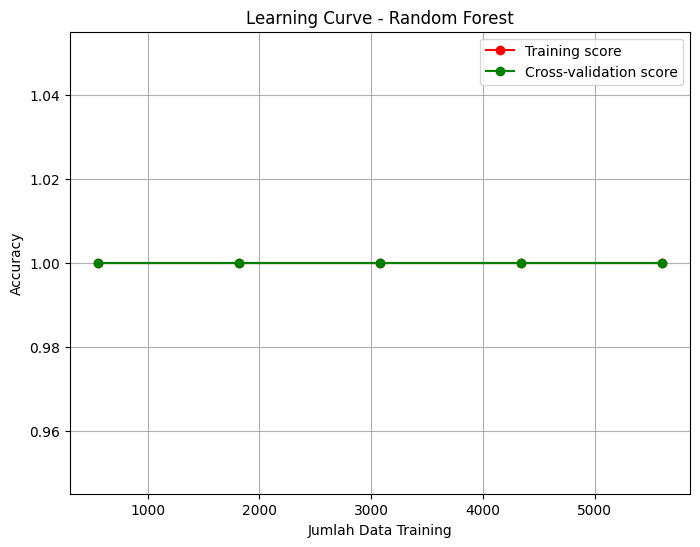

In [15]:
# Contoh: menggunakan Random Forest sebagai model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Rata-rata CV Accuracy:", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.title('Learning Curve - Random Forest')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan ini untuk mengetahui apakah pemodelan dengan **Random Forest** mengalami overfitting atau tidak. Oleh sebab itu, saya menggunakan **cross-validation** dan melihat **learning curve**. Dari hasil yang ditunjukkan:

1. **Nilai cross-validation accuracy** konsisten di angka **1.0** untuk setiap fold.  
2. **Kurva pembelajaran (learning curve)** menunjukkan **training score** dan **cross-validation score** sama-sama berada di sekitar nilai 1.0 tanpa adanya celah (gap) yang berarti.

Berdasarkan kedua poin tersebut, secara **teknis** tidak terlihat tanda-tanda overfitting karena performa di data latih dan validasi sama-sama sempurna. Namun, **akurasinya yang 1.0** ini tetap perlu diwaspadai karena:

- **Data mungkin terlalu sedikit** atau **terlalu mudah** diprediksi, sehingga model dapat “menghafal” pola data dengan sangat mudah.  
- Kejadian akurasi sempurna ini **jarang** terjadi di kondisi dunia nyata, sehingga kita perlu **verifikasi lebih lanjut** dengan menambah data baru atau menggunakan data uji terpisah yang benar-benar berbeda.

Dengan kata lain, **secara indikator overfitting**, model Random Forest ini belum menunjukkan perbedaan performa di data latih dan validasi. Namun, **hasil yang sempurna** mendorong kita untuk melakukan **pengecekan lebih mendalam** guna memastikan apakah performa tersebut benar-benar mencerminkan kemampuan generalisasi model atau hanya cerminan dataset yang terbatas.

Cross-Validation Accuracy Scores (MLP): [1. 1. 1. 1. 1.]
Rata-rata CV Accuracy (MLP): 1.0


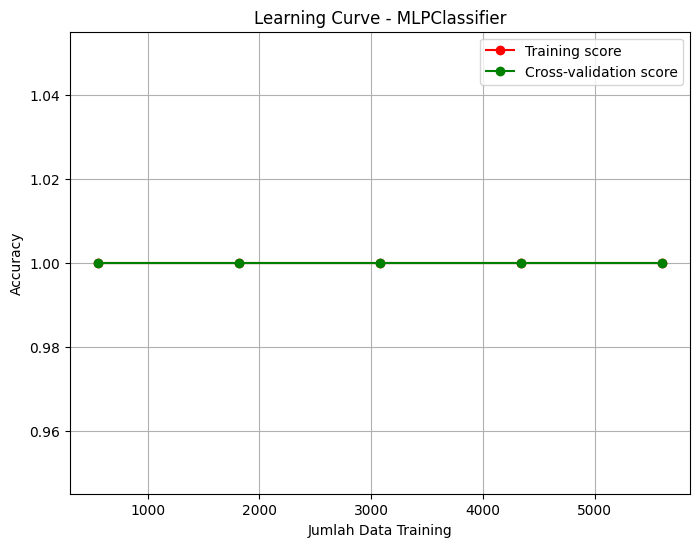

In [17]:
mlp_model = MLPClassifier(random_state=42, max_iter=1000)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(mlp_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores (MLP):", cv_scores)
print("Rata-rata CV Accuracy (MLP):", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    mlp_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.1,
    color="r"
)
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(
    train_sizes,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.1,
    color="g"
)
plt.title('Learning Curve - MLPClassifier')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan ini untuk mengetahui apakah pemodelan dengan **Multi Layer Perceptron (MLP)** mengalami overfitting atau tidak. Oleh sebab itu, saya menggunakan **cross-validation** dan melihat **learning curve**. Dari hasil yang ditunjukkan:

1. **Nilai cross-validation accuracy** konsisten di angka **1.0** untuk semua fold.  
2. **Kurva pembelajaran (learning curve)** menunjukkan **training score** dan **cross-validation score** sama-sama berada di sekitar nilai 1.0 tanpa ada celah (gap) yang signifikan.

Berdasarkan kedua hal tersebut, secara **teknis** tidak terlihat tanda-tanda overfitting karena tidak ada perbedaan antara performa di data latih dan data validasi. Namun, **akurasinya yang sempurna (1.0)** pada kedua set data menimbulkan dugaan bahwa:

- **Data mungkin terlalu sedikit** atau **terlalu mudah** diprediksi, sehingga model bisa “menghafal” seluruh pola dengan sangat mudah.  
- Kondisi ini jarang terjadi pada kasus nyata, sehingga perlu **verifikasi lebih lanjut**. Misalnya dengan menambah data baru, menggunakan data test terpisah, atau menerapkan metode validasi lain (seperti *repeated cross-validation*).

Jadi, dari hasil learning curve dan cross-validation, **model MLP belum menunjukkan indikasi overfitting**, tetapi akurasi sempurna ini tetap perlu diinvestigasi lebih lanjut untuk memastikan bahwa performa model memang benar-benar merefleksikan kemampuan generalisasi yang baik, bukan sekadar “hapalan” pada dataset terbatas.

Sebelumnya saya curiga bahwa model Multi Layer Perceptron (MLP) dan Random Forest ini mengalami overfitting, karena kedua model tersebut sudah menghasilkan akurasi 1.0 sejak awal pemodelan. Oleh sebab itu, saya melakukan cross-validation dan pemeriksaan kurva metrik (learning curve) untuk memastikan apakah model tersebut benar-benar overfitting atau tidak. Hasilnya, karena nilai cross-validation juga konsisten tinggi dan tidak berbeda jauh dengan training score, maka model belum menunjukkan tanda-tanda overfitting.

Namun, saya pikir hal ini terjadi karena data yang terlalu sedikit sehingga model mudah sekali untuk memahami dataset, atau karakteristik dataset yang memang terlalu mudah diprediksi, karena mendapatkan akurasi 1.0 secara konsisten biasanya jarang terjadi di dunia nyata.

## 3. Rekomendasi apa yang anda berika untuk next pemodelannya

Menurut saya untuk **Rekomendasi ke Tahap Pemodelan Selanjutnya** ada beberapa diantaranya yaitu: 

1. **Mengumpulkan atau Menggunakan Lebih Banyak Data**  
   - Dengan data yang lebih banyak, model akan lebih menantang untuk “menghafal” pola secara sempurna dan dapat menghasilkan evaluasi yang lebih realistis.

2. **Menggunakan Metode Validasi yang Lebih Beragam**  
   - Selain cross-validation standar, Anda dapat mencoba *repeated cross-validation* atau *stratified k-fold cross-validation* untuk memastikan hasil benar-benar konsisten.

3. **Menggukur Kinerja dengan Metrik Tambahan**  
   - Selain akurasi, pertimbangkan metrik seperti *precision, recall, F1-score*, atau *AUC-ROC* untuk mendapatkan gambaran kinerja model yang lebih menyeluruh.

4. **Mengecek Distribusi dan Kompleksitas Fitur**  
   - Pastikan data yang digunakan cukup variatif dan tidak terlalu mudah diprediksi. Jika perlu, pertimbangkan untuk menambah fitur baru yang relevan atau melakukan *feature engineering*.

5. **Evaluasi di Data atau Lingkungan Nyata**  
   - Uji model di data uji (test set) yang benar-benar terpisah atau data baru (jika memungkinkan) untuk memastikan performa tidak hanya tinggi di data yang sudah dikenal.

6. **Mempertimbangkan Regularisasi atau Penyesuaian Arsitektur Model**  
   - Untuk model MLP, Anda bisa mencoba *early stopping*, *dropout*, atau menyesuaikan jumlah neuron dan lapisan agar tidak terlalu kompleks untuk dataset yang relatif kecil.  
   - Untuk Random Forest, Anda bisa menyesuaikan *max_depth* atau parameter lain yang membatasi kompleksitas pohon.

Dengan langkah-langkah tersebut, Anda dapat memastikan bahwa model tidak hanya mencapai akurasi tinggi di dataset terbatas, tetapi juga benar-benar memiliki kemampuan generalisasi yang baik.